# 1.8 Resource allocation

**Responsible:** _(Aldo Patrone)_

Resource allocation is **random** in Part I ("resources/allocation.py", "RandomAllocation"): among the resources that are permitted (1.7) ∩ available (1.6) ∩ free, one is chosen uniformly at random. There is nothing to fit offline, so this notebook just documents the strategy and sanity-checks it:

1. **Determinism** under a fixed seed (reproducible simulations).
2. **Uniformity** of the random choice over the candidate set.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from collections import Counter
import matplotlib.pyplot as plt
from resources.allocation import RandomAllocation

candidates = {'User_A', 'User_B', 'User_C', 'User_D'}

# 1) determinism: same seed -> identical pick sequence
seq1 = [RandomAllocation(seed=7).pick(candidates) for _ in range(1)]
a, b = RandomAllocation(seed=7), RandomAllocation(seed=7)
same = all(a.pick(candidates) == b.pick(candidates) for _ in range(1000))
print('deterministic under fixed seed:', same)
print('empty candidate set -> None:', RandomAllocation(seed=7).pick(set()) is None)

deterministic under fixed seed: True
empty candidate set -> None: True


pick counts (expected ~10000 each): {'User_A': 10018, 'User_B': 10053, 'User_C': 9854, 'User_D': 10075}
chi-square uniformity: chi2=3.01, dof=3, p=0.390 -> fail to reject uniformity


saved ../results/allocation_uniformity.png


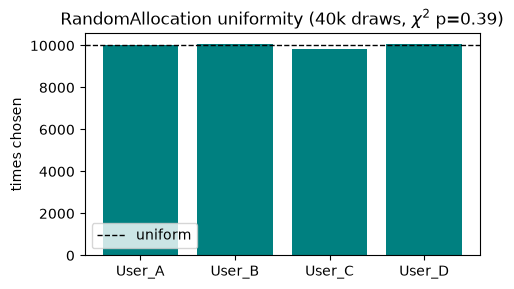

In [2]:
# 2) uniformity over the candidate set
from scipy.stats import chisquare
ra = RandomAllocation(seed=1)
counts = Counter(ra.pick(candidates) for _ in range(40000))
print('pick counts (expected ~10000 each):', dict(sorted(counts.items())))

# goodness-of-fit test, H0 uniform, expected 40000/len(candidates) per bin
obs = [counts[k] for k in sorted(counts)]
chi, p = chisquare(obs)
print('chi-square uniformity: chi2=%.2f, dof=%d, p=%.3f -> %s'
      % (chi, len(obs) - 1, p, 'fail to reject uniformity' if p > 0.05 else 'reject'))

fig, ax = plt.subplots(figsize=(5, 3))
ks = sorted(counts)
ax.bar(ks, [counts[k] for k in ks], color='teal')
ax.axhline(40000 / len(candidates), color='k', ls='--', lw=1, label='uniform')
ax.set_ylabel('times chosen')
ax.set_title('RandomAllocation uniformity (40k draws, $\\chi^2$ p=%.2f)' % p); ax.legend()
fig.tight_layout(); fig.savefig('../results/allocation_uniformity.png', dpi=120)
print('saved ../results/allocation_uniformity.png')

**Result:** The allocation is reproducible under a fixed seed and uniform over the eligible candidates, returning "None" (-> the core suspends the activity) when no resource is free. This is the unbiased baseline the assignment requires for Part 1. An optimized policy is the subject of Part II.